In [1]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [2]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [3]:
""" ARCH(1) Hidden Markov Model sigma_{t}^2 = alpha_{0,s_{t}} + alpha_{1,s_{t}} * Y_{t-1}^2 """

# Number of hidden states k
k = 2

# Setting up initial ARCH(1) parameters alpha_0 and alpha_1
alpha_0 = np.array([0.1, 0.5])
alpha_1 = np.array([0.2, 0.7])

# Transition matrix P
P = np.array([
    [0.98, 0.02],
    [0.05, 0.95]
])

# States and time series values y together with variances var
states = np.zeros(T, dtype=int)
y = np.zeros(T)
var = np.zeros(T)

# Setting up initial states, time series values, and variance
states[0] = np.random.choice(k)
y[0] = np.random.normal(loc=0, scale=np.sqrt(var[0]))
var[0] = alpha_0[states[0]]

# Looping through the time steps t in T 
for t in range(1, T):

    # Finding states at time t and saving to variable s
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    # Finding the variances at time step t which is 
    # alpha_0 for state s plus alpha_1 for state s
    # times the time series value of last step squared  
    var[t] = alpha_0[s] + alpha_1[s] * (y[t-1]**2)
    
    # The time series value at time s is then the random variable
    # given variance var at time step t 
    y[t] = np.random.normal(loc=0, scale=np.sqrt(var[t]))

    # Printing out the 100th time steps
    if t % 100 == 0:
        print(f"t={t:<5} State: {s:<3} Variance: {var[t]:>6.2f}  y: {y[t]:>6.2f}")

t=100   State: 1   Variance:   0.56  y:  -0.01
t=200   State: 0   Variance:   0.13  y:   0.53
t=300   State: 0   Variance:   0.12  y:  -0.00
t=400   State: 0   Variance:   0.12  y:   0.11
t=500   State: 0   Variance:   0.12  y:   0.02
t=600   State: 0   Variance:   0.12  y:   1.08
t=700   State: 0   Variance:   0.10  y:   0.14
t=800   State: 0   Variance:   0.10  y:   0.15
t=900   State: 0   Variance:   0.12  y:  -0.37


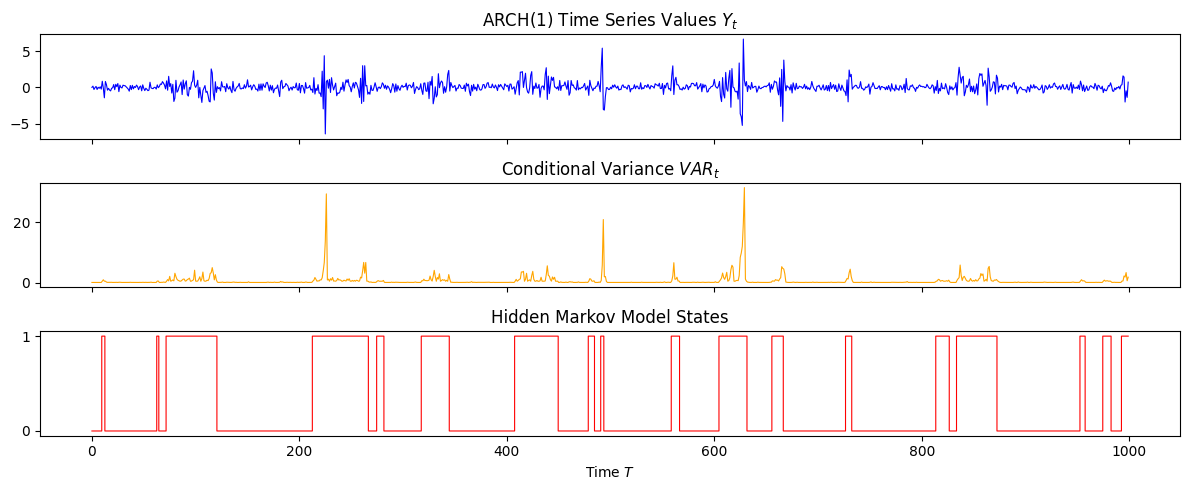

In [ ]:
""" Plotting figure """

# Setting up an environment with three panels stacked
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

# First panel
ax1.plot(y, color='blue', linewidth=0.8)
ax1.set_title("ARCH(1) Time Series Values $Y_t$")

# Second panel
ax2.plot(var, color='orange', linewidth=0.8)
ax2.set_title(f"Conditional Variance $VAR_t$")

# Third panel 
ax3.plot(states, color='red', drawstyle='steps-mid', linewidth=0.8)
ax3.set_title("Hidden Markov Model States")
ax3.set_yticks([0, 1])

# Arguments for both panels
plt.xlabel("Time $T$")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"arch1-hmm.pdf"), bbox_inches="tight")
plt.show()